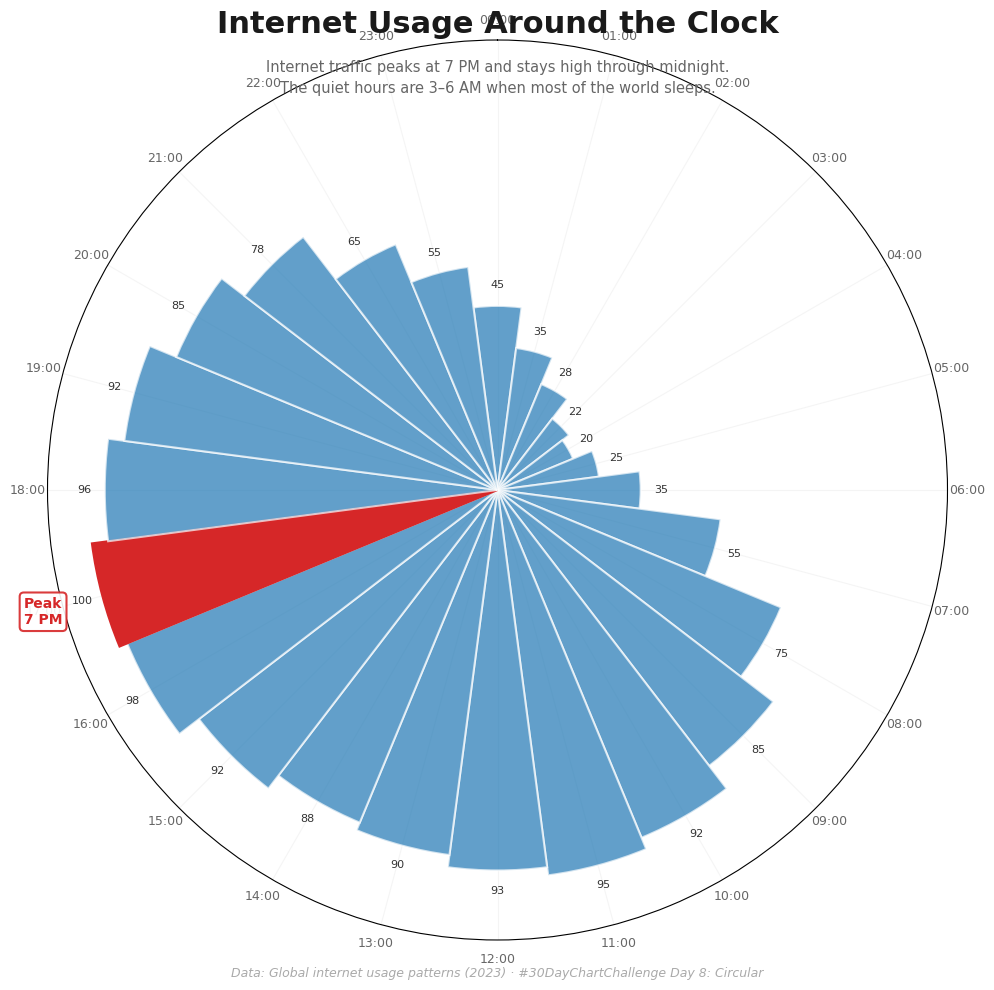

In [1]:
"""
#30DayChartChallenge — Day 8: Circular
"Internet Usage Around the Clock" — circular/radial distribution
in the style of FlowingData: minimal chrome, direct labels, clean typography.

Data: Internet usage patterns by hour of day (2023)
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------------
# 1. SAMPLE DATA — Internet usage by hour of day (relative traffic index)
# ---------------------------------------------------------------------------
data = {
    "Hour": list(range(0, 24)),
    "Hour_Label": [f"{h:02d}:00" for h in range(0, 24)],
    "Traffic": [
        45, 35, 28, 22, 20, 25, 35, 55, 75, 85,
        92, 95, 93, 90, 88, 92, 98, 100, 96, 92,
        85, 78, 65, 55
    ]
}

df = pd.DataFrame(data)

# Normalize for better visualization
df["Traffic_Norm"] = df["Traffic"] / df["Traffic"].max()

# ---------------------------------------------------------------------------
# 2. PLOT — Circular/Radial Bar Chart
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 10), facecolor="#FFFFFF", 
                       subplot_kw=dict(projection="polar"))
ax.set_facecolor("#FFFFFF")

# Setup angles (24 hours = 360 degrees)
angles = np.linspace(0, 2*np.pi, len(df), endpoint=False)
traffic_values = df["Traffic"].values
labels = df["Hour_Label"].values

# Create radial bars
bars = ax.bar(angles, traffic_values, width=2*np.pi/24, alpha=0.7, 
              color="#1f77b4", edgecolor="white", linewidth=1.5, zorder=3)

# Highlight peak hour (19:00 / 7 PM)
peak_idx = df["Traffic"].idxmax()
bars[peak_idx].set_color("#d62728")
bars[peak_idx].set_alpha(1.0)

# Add radial gridlines (light)
ax.set_ylim(0, df["Traffic"].max() * 1.1)
ax.grid(True, color="#eeeeee", linewidth=0.8, alpha=0.6, zorder=0)
ax.set_axisbelow(True)

# Remove default radial labels, add custom ones
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles)
ax.set_xticklabels(labels, fontsize=9, color="#666666")
ax.set_yticks([])

# Add value labels on bars
for angle, traffic, label in zip(angles, traffic_values, labels):
    height = traffic
    ax.text(angle, height + df["Traffic"].max() * 0.05, f"{traffic:.0f}",
            ha="center", va="center", fontsize=8, color="#333333", fontweight="500")

# Peak hour annotation
peak_angle = angles[peak_idx]
peak_traffic = traffic_values[peak_idx]
ax.text(peak_angle, peak_traffic + df["Traffic"].max() * 0.15,
        "Peak\n7 PM", ha="center", va="center", fontsize=10, 
        fontweight="bold", color="#d62728", bbox=dict(boxstyle="round,pad=0.3",
        facecolor="#fff", edgecolor="#d62728", linewidth=1.5, alpha=0.9))

# Title & subtitle (outside plot)
fig.text(0.5, 0.98, "Internet Usage Around the Clock",
         fontsize=22, fontweight="bold", color="#1a1a1a", ha="center", va="top")

fig.text(0.5, 0.93,
         "Internet traffic peaks at 7 PM and stays high through midnight.\n"
         "The quiet hours are 3–6 AM when most of the world sleeps.",
         fontsize=10.5, color="#666666", ha="center", va="top", linespacing=1.5)

# Source
fig.text(0.5, 0.01,
         "Data: Global internet usage patterns (2023) · #30DayChartChallenge Day 8: Circular",
         fontsize=9, color="#aaaaaa", style="italic", ha="center", va="bottom")

plt.tight_layout()
plt.savefig("day8_circular.png", dpi=200, facecolor="#FFFFFF", bbox_inches="tight")
plt.show()